<a href="https://colab.research.google.com/github/shio0418/ML_exercise/blob/main/ml2024_04_classification_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 演習4. 分類

適切な題材を選び、分類モデル（二値分類でも多値分類でも何でも可）を学習せよ。ただし、以下の観点で採点を行うので、これらを満たすように解答せよ。

## 1. タスクの説明

選んだ分類タスクの概要（入力と出力が何であるか等）を説明せよ。<!-- 2(1) -->

今回はロジスティック回帰を用い、与えられた画像がTシャツ・ズボン・ドレスなどの服飾品のうちどれになるか分類する。データの詳細については以下で述べる。

## 2. データの入手方法・構築方法

分類モデルを学習するための訓練データ、検証データ、評価データの入手方法を説明せよ。データを自作した場合は、作成方法を説明せよ。<!-- 2(2) -->

今回は、fashionMnistデータセットを用い分類を行う。各データのラベルと名前は以下の通りに対応している。
画像データは2次元配列なので、フラット化し標準化している。
目的変数をoneHotベクトル化したところモデルの学習がうまくいかなかったので、今回は数値のまま学習を行う。

| ラベル | 名前 |
| ---- | ---- |
| 0 |  T-shirt/top（Tシャツ/トップス） |
| 1 | Trouser（ズボン） |
| 2 | Pullover（プルオーバー、頭から被って着る服） |
| 3 | Dress（ドレス） |
| 4 | Coat（コート） |
| 5 | Sandal（サンダル） |
| 6 | Shirt（シャツ） |
| 7 | Sneaker（スニーカー） |
| 8 | Bag（バッグ） |
| 9 | Ankle boot（アンクルブーツ、かかとが隠れる丈のブーツ） |


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml


def images_to_vectors(X):
    return np.reshape(X, (len(X), -1))  # Flatten: (N x 28 x 28) -> (N x 784)

fashion_mnist = fetch_openml('Fashion-MNIST')
X = fashion_mnist.data
y = fashion_mnist.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

X_train /= 255
X_test /= 255         #画像データを0~1の範囲にスケーリング
X_train = images_to_vectors(X_train)    #2次元データを１次元に平坦化
X_test = images_to_vectors(X_test)

#y_train = np.eye(10)[y_train] #one-hotベクトルに変換→modelfitするときにエラーがでた
#_test = np.eye(10)[y_test]

y_train = np.array(y_train) # y_batchを計算するためnumpy配列にする
y_test = np.array(y_test)








## 3. モデルの学習

訓練データで分類モデルを確率的勾配降下法により学習せよ。このとき、各エポック毎に以下の評価値を計算し、グラフとして表示せよ。

+ 訓練データ上の損失関数の値
+ 訓練データ上の正解率
+ 検証データ上の損失関数の値
+ 検証データ上の正解率

※もし、学習にライブラリを使った場合、このグラフを表示する手段が用意されていない場合がある。その場合は、その旨を説明したうえで、学習終了時の上記４種類の値を報告すればよい。

<!-- 2(3) -->

In [ ]:
#for文でepochごとに損失関数・正解率を表示させたかったので増分学習みたいなことをさせる
 #(参考)https://kakedashi-engineer.appspot.com/2020/03/09/scikit-learn-8/
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
max_epochs =  50000
eta_0 = 0.01
eps = 1e-4
batch_size = 100

train_losses = []
test_losses = []
train_corrects = []
test_corrects = []
#誤分類されたインデックスを保存
misclassified = {i: [] for i in range(10)}
#学習率がエポック数ごとに減少していくよう設定
model = SGDClassifier(loss='log_loss', max_iter=1,eta0=eta_0,learning_rate='invscaling',warm_start=True)

for t in range(max_epochs):
    batch = np.random.choice(X_train.shape[0], batch_size)
    #バッチ学習をさせる
    X_train_batch = X_train[batch]
    y_train_batch = y_train[batch]
    model.partial_fit(X_train_batch, y_train_batch, classes=[0,1,2,3,4,5,6,7,8,9])

    if t % 1000 == 0:
        train_corrects.append(model.score(X_train, y_train))
        test_corrects.append(model.score(X_test, y_test))

        train_losses.append(log_loss(y_train, model.predict_proba(X_train)))
        test_losses.append(log_loss(y_test, model.predict_proba(X_test)))
        print(f'epoch: {t}|test loss',train_losses[-1])

        y_pred = model.predict(X_test)

        for i, (true_label, pred_label) in enumerate(zip(y_test, y_pred)):
            if true_label != pred_label:
                misclassified[true_label].append(i)


print("Train Corrects:", model.score(X_train, y_train))
print("Test Corrects:", model.score(X_test, y_test))
print(f'Training loss : {train_losses[-1]}')
print(f'Testing loss : {test_losses[-1]}')

epoch: 0|test loss 2.0365653649495203
epoch: 1000|test loss 0.9057186724803868
epoch: 2000|test loss 0.8418639341332486
epoch: 3000|test loss 0.8085252885314187
epoch: 4000|test loss 0.7869528766754594
epoch: 5000|test loss 0.7714180921135009
epoch: 6000|test loss 0.758908703485982
epoch: 7000|test loss 0.7464348708315561
epoch: 8000|test loss 0.7373350701752622
epoch: 9000|test loss 0.7299188923062827
epoch: 10000|test loss 0.7236561122187072
epoch: 11000|test loss 0.7171009108916304
epoch: 12000|test loss 0.7120002682443064
epoch: 13000|test loss 0.7068756483148749
epoch: 14000|test loss 0.7023451210355733
epoch: 15000|test loss 0.6982969143340692
epoch: 16000|test loss 0.6943841792279098
epoch: 17000|test loss 0.6910475958730546
epoch: 18000|test loss 0.6872959404636583
epoch: 19000|test loss 0.6842474183071882
epoch: 20000|test loss 0.6813628733159072
epoch: 21000|test loss 0.6780659863282298
epoch: 22000|test loss 0.6754481567545544
epoch: 23000|test loss 0.6728104726197071
epoch:

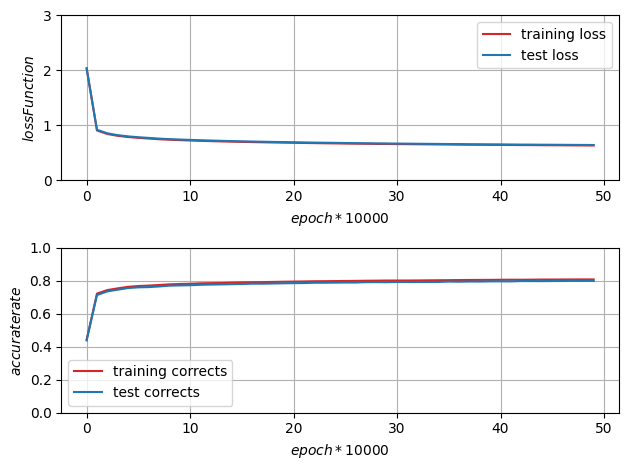

Final training loss : 0.6325072350756583
Final testing loss : 0.6412241088647296
Final training accuracy : 0.8092142857142857
Final testing accuracy : 0.8001428571428572


In [ ]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(train_losses,label='training loss',color='tab:red')
ax1.plot(test_losses,label='test loss ',color='tab:blue')
ax2.plot(train_corrects,label='training corrects',color='tab:red')
ax2.plot(test_corrects,label='test corrects',color='tab:blue')
ax1.set_ylim(0, 3)
ax1.grid()
ax1.legend()
ax1.set_xlabel('$epoch * 1000$')
ax1.set_ylabel('$loss Function$')
ax2.set_ylim(0, 1)
ax2.grid()
ax2.legend()
ax2.set_xlabel('$epoch * 1000$')
ax2.set_ylabel('$accurate rate$')
fig.tight_layout()
plt.show()

print(f'Final training loss : {train_losses[-1]}')
print(f'Final testing loss : {test_losses[-1]}')
print(f'Final training accuracy : {train_corrects[-1]}')
print(f'Final testing accuracy : {test_corrects[-1]}')

## 4. 適合率、再現率、F1スコア

(3)で学習したモデルに対して、評価データ上で以下の評価値を計算せよ。

+ 各分類カテゴリに対する適合率、再現率、F1スコア
+ 各カテゴリの適合率、再現率、F1スコアのマクロ平均を取ったもの<!-- 2(4) -->

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
y_test_pred = model.predict(X_test)
preScore = precision_score(y_test, y_test_pred, average=None)
reScore = recall_score(y_test, y_test_pred, average=None)
f1Score = f1_score(y_test, y_test_pred, average=None)
print("適合率 : ", ", ".join([f"{score:.5f}" for score in preScore]))
print("再現率 : ", ", ".join([f"{score:.5f}" for score in reScore]))
print("F1スコア : ", ", ".join([f"{score:.5f}" for score in f1Score]))

適合率 :  0.75356, 0.96496, 0.68759, 0.76471, 0.66626, 0.95122, 0.67405, 0.82213, 0.89606, 0.83871
再現率 :  0.79799, 0.92837, 0.69766, 0.85773, 0.78674, 0.78168, 0.43381, 0.86706, 0.93214, 0.93976
F1スコア :  0.77514, 0.94631, 0.69259, 0.80855, 0.72151, 0.85815, 0.52788, 0.84400, 0.91374, 0.88636


## 5. 混同行列

(3)で学習したモデルに対して、評価データ上で混同行列を計算せよ。<!-- 2()5) -->

In [ ]:
from sklearn.metrics import confusion_matrix
y_test_pred = model.predict(X_test)
confusion_matrix(y_test, y_test_pred)

array([[1104,    9,   28,  171,    9,    0,   39,    0,   29,    2],
       [   9, 1311,   27,   62,   12,    0,    1,    0,    2,    0],
       [  19,    2,  927,   11,  305,    0,   71,    1,   29,    1],
       [  57,   22,   17, 1247,   67,    0,   37,    0,    8,    0],
       [   0,    2,  199,   80, 1037,    0,   57,    0,   12,    1],
       [   2,    0,    0,    2,    0,  809,    0,  346,   35,  203],
       [ 326,    4,  235,   93,  318,    0,  437,    1,   59,    0],
       [   0,    0,    0,    0,    0,   22,    0, 1165,    4,  163],
       [   3,    1,   13,   29,    8,    3,   15,   19, 1245,    5],
       [   0,    0,    0,    1,    0,    3,    1,   73,    3, 1330]])

## 6. 失敗分析

評価データの中に、(3)で学習したモデルが正しく分類できないものがあることが通常である。分類に失敗する事例について、その原因を分析・考察せよ。<!-- 2(6) -->

| ラベル | 名前 |
| ---- | ---- |
| 0 |  T-shirt/top（Tシャツ/トップス） |
| 1 | Trouser（ズボン） |
| 2 | Pullover（プルオーバー、頭から被って着る服） |
| 3 | Dress（ドレス） |
| 4 | Coat（コート） |
| 5 | Sandal（サンダル） |
| 6 | Shirt（シャツ） |
| 7 | Sneaker（スニーカー） |
| 8 | Bag（バッグ） |
| 9 | Ankle boot（アンクルブーツ、かかとが隠れる丈のブーツ） |

# 考察
今回のデータセットでは、データ数は60,000と十分に多く、特徴量も画像データのため十分にあった。また、欠損値もなくデータとしては問題なかったと考えられる。
訓練データと評価データ間の大きな損失関数・正解率のズレも見られていない。
しかし、正解率は8割ほどで、学習率を0.01から0.001の範囲まで0.001刻みで変更し試したが小さくすればするほど正解率は悪くなってしまった。
そこで、サイト（https://qiita.com/code0327/items/5dfc1b2ed143c1f9bd2b）
を利用して分類できなかった画像を表示してみた。(なぜか１以降は分類できた画像も表示してしまっているが、原因がわからなかった)
   

### 失敗例の分析
失敗例をみてみたところ、人間の目から見ても分類が難しい画像が含まれていた。特に成功例と違い形が独特だったり、色合いが特殊だったり、全体的に白っぽく外形を掴むのが難しかったりした。
また、今回ラベル０〜４、６が洋服で、５、7、9は靴、８がカバンである。混同行列に注目すると、
まず洋服同士や靴同士を誤分類するケースが多く見受けられている。特にサンダルの精度が低く、正解数809に比べてスニーカに誤分類したケースが346件、アンクルブーツに誤分類したケースが203件ほどあった。
全体的に最も正解率が低かったラベルは６のシャツであり、Tシャツ、プルオーバー、ドレス、コートなどにも多く分類されてしまっている。正直このデータでは私の目からしてもシャツの分類は難しいので、そもそものデータの解像度を上げたり、色彩をつけたり、別アングルからの写真を追加するなどの対策が必要かもしれない。




線形分類に限界があったことも理由の一つの可能性があるが、ニューラルネットワークでの実装を試す時間が取れなかったため試していない。

■ 正解値「0」に対して正しく予測（分類）できなかったケース


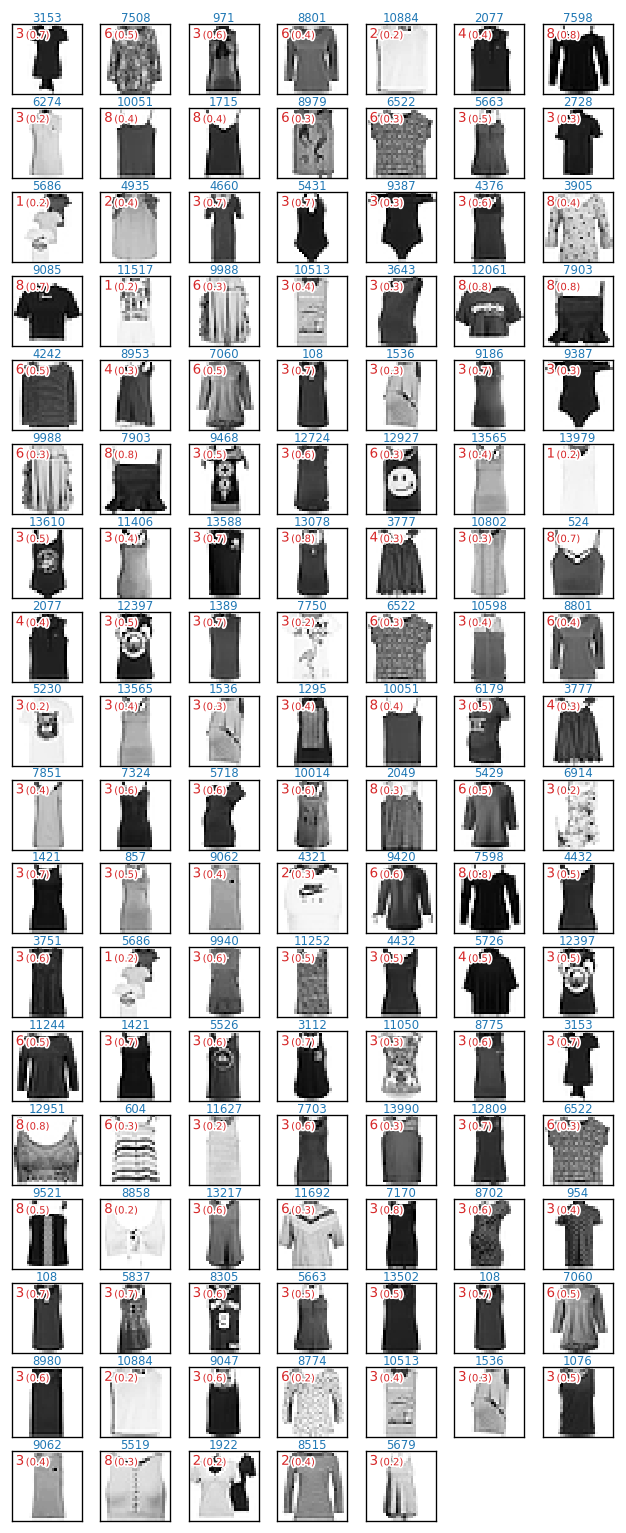

■ 正解値「1」に対して正しく予測（分類）できなかったケース


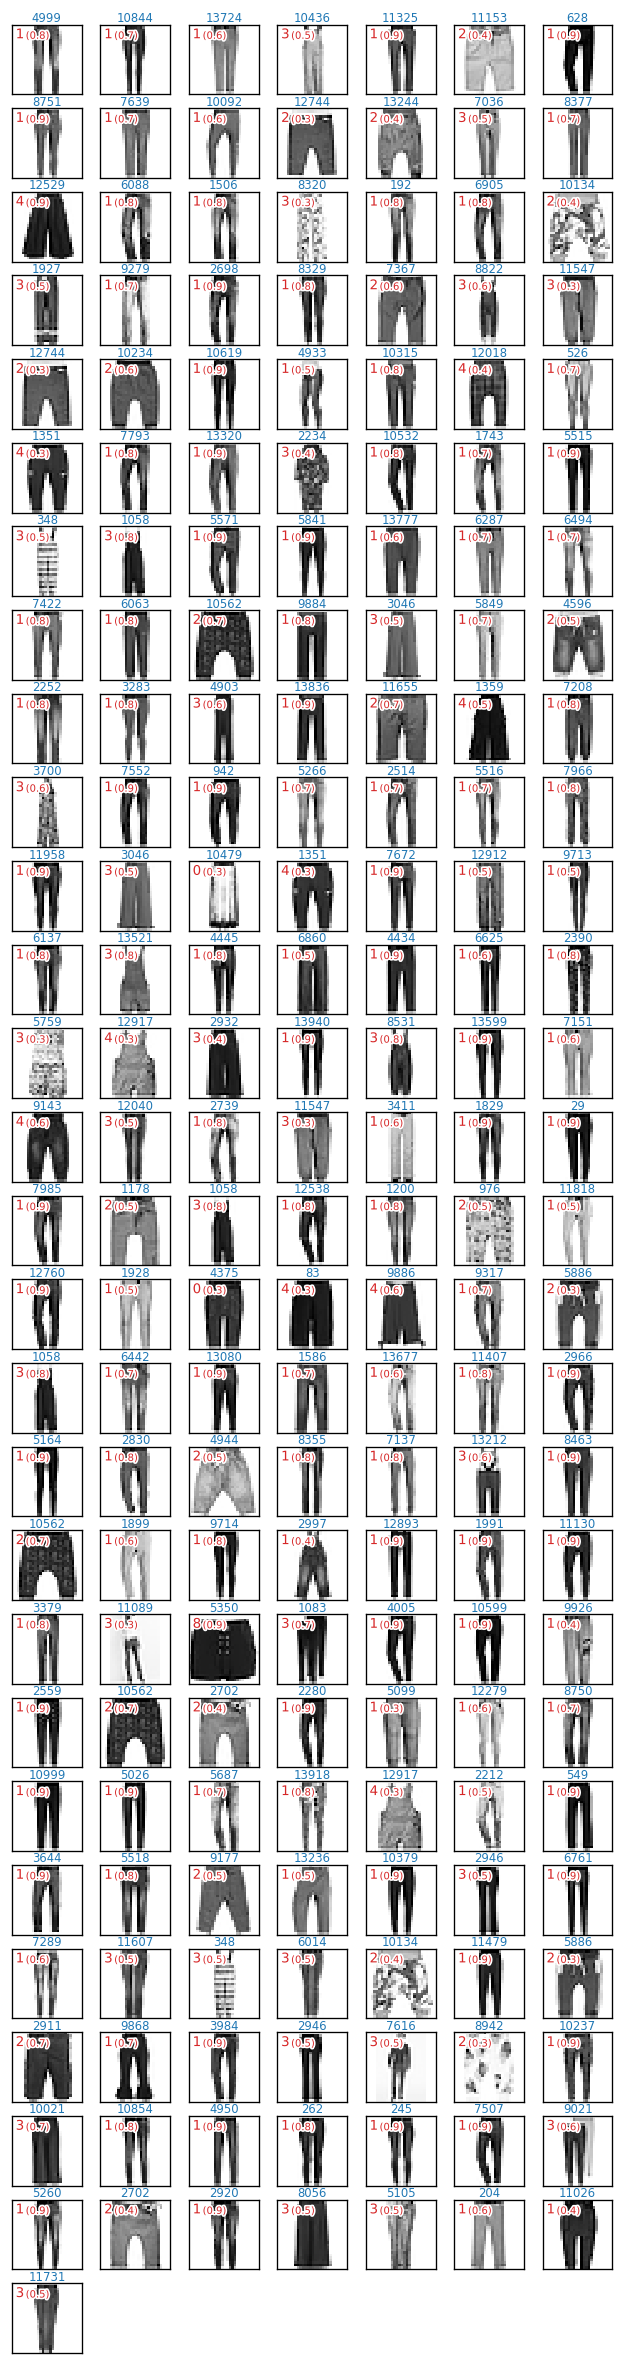

■ 正解値「2」に対して正しく予測（分類）できなかったケース


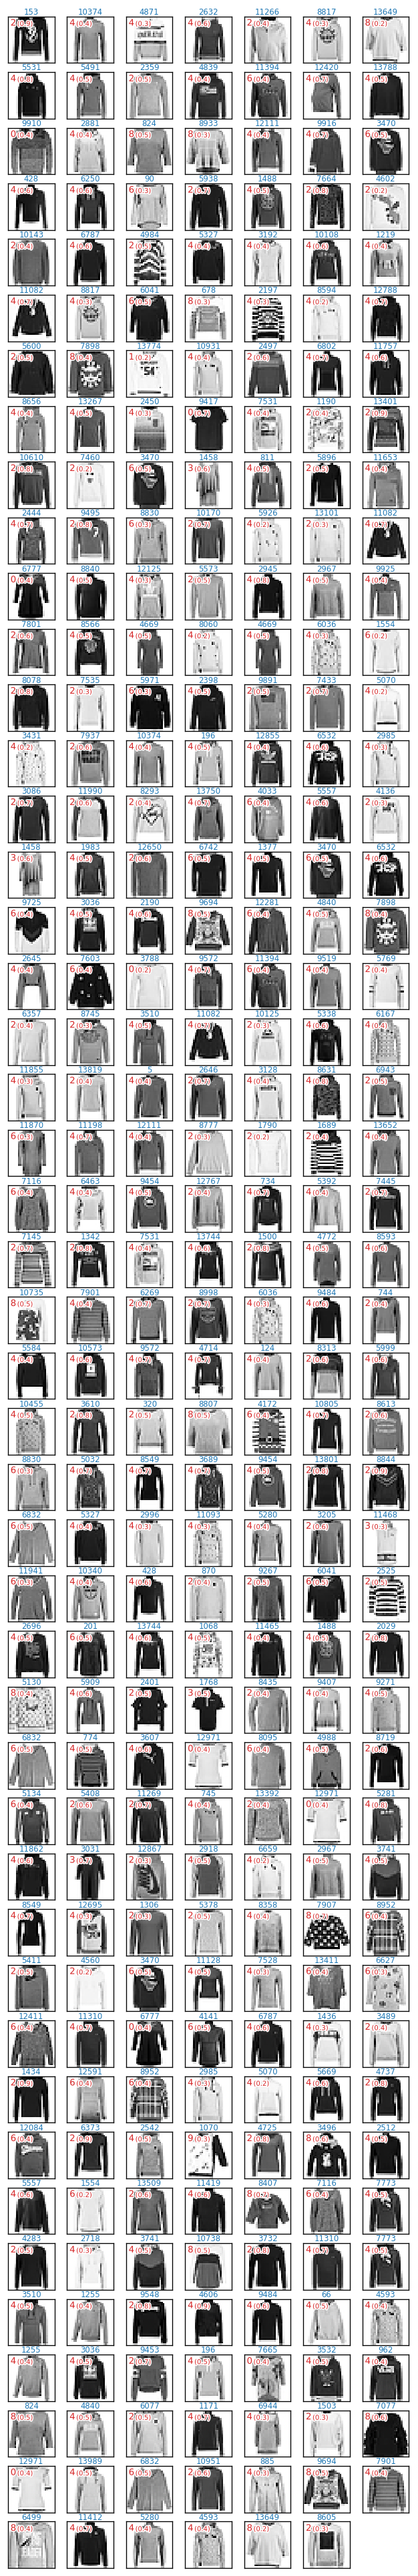

■ 正解値「3」に対して正しく予測（分類）できなかったケース


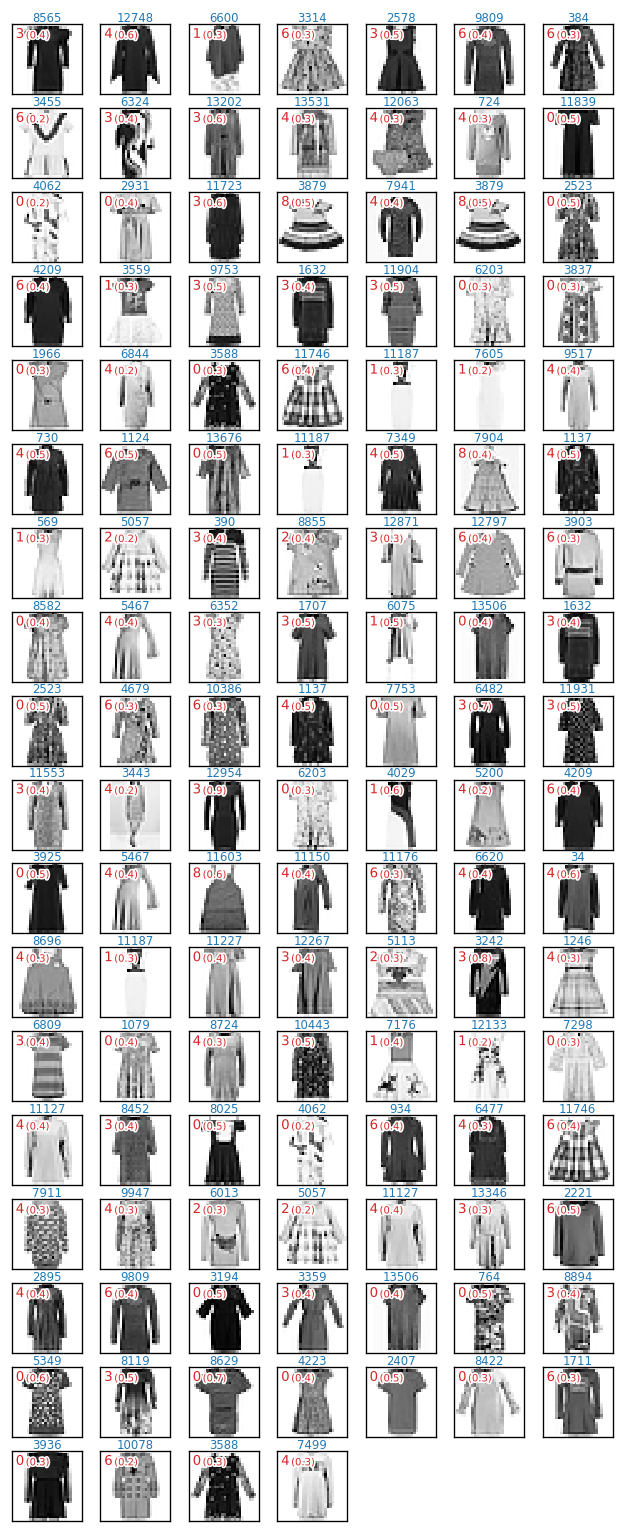

■ 正解値「4」に対して正しく予測（分類）できなかったケース


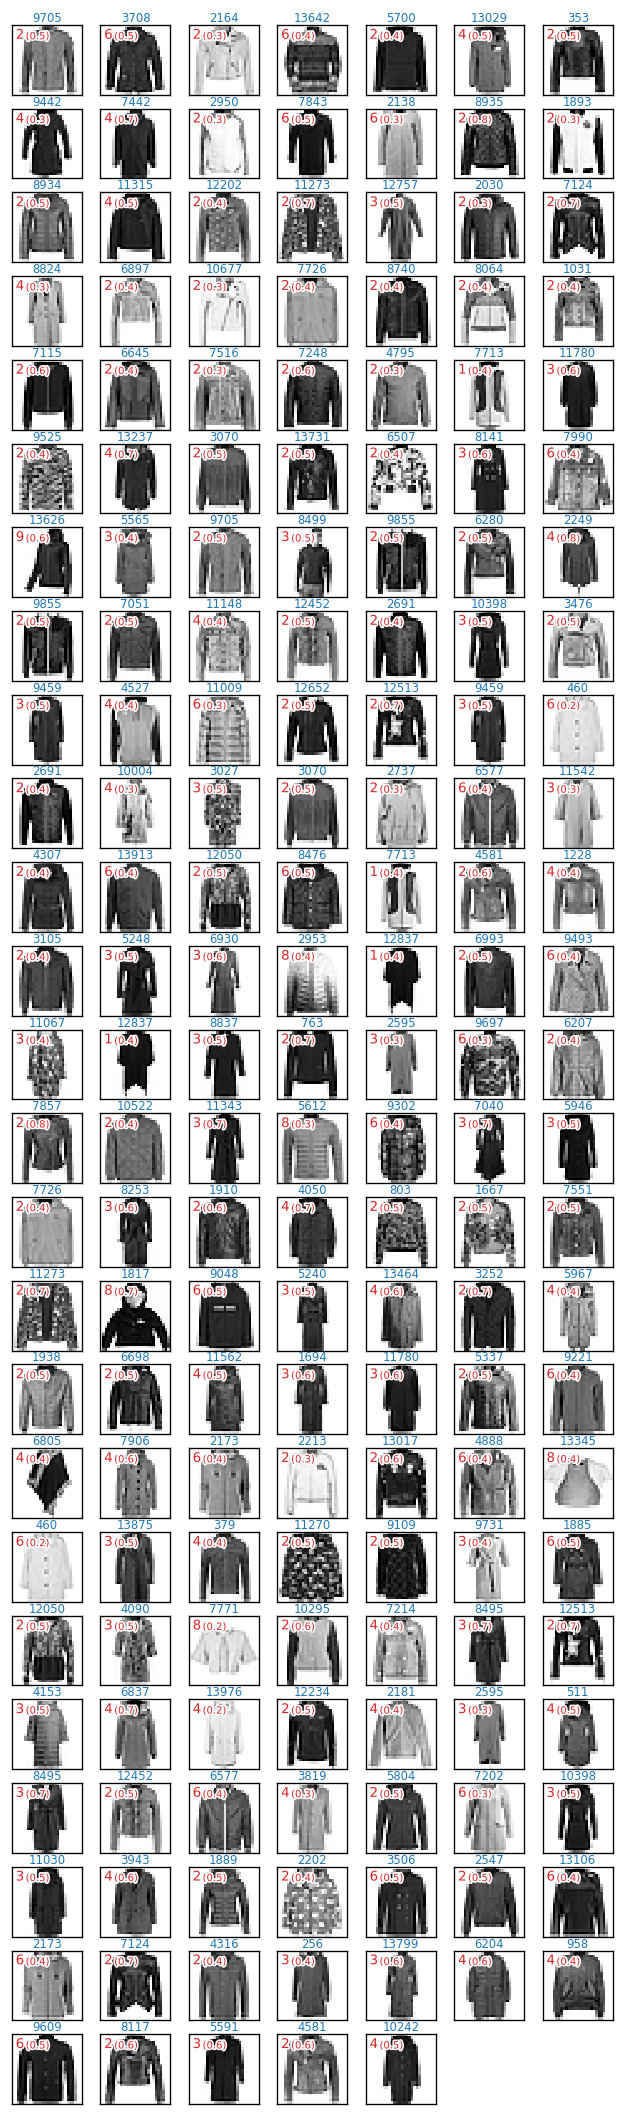

■ 正解値「5」に対して正しく予測（分類）できなかったケース


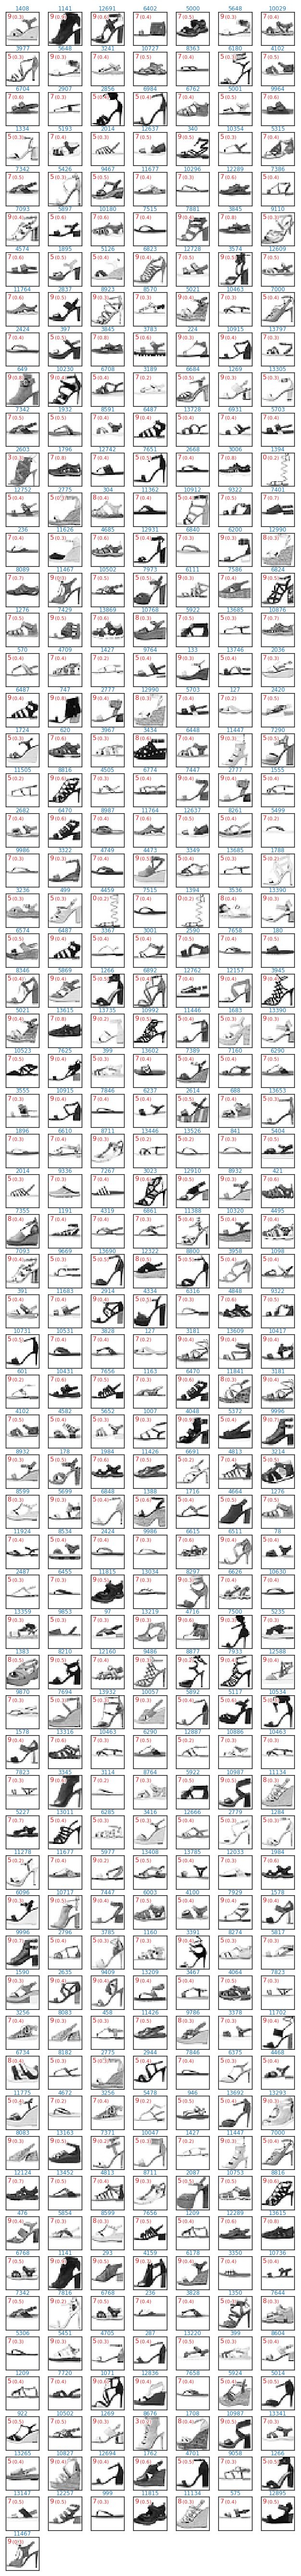

■ 正解値「6」に対して正しく予測（分類）できなかったケース


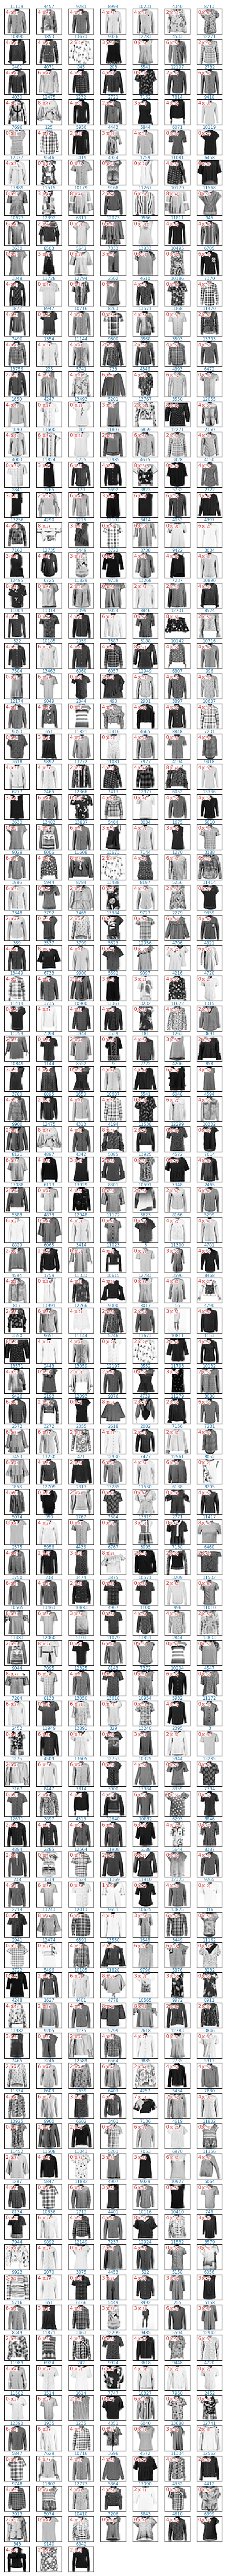

■ 正解値「7」に対して正しく予測（分類）できなかったケース


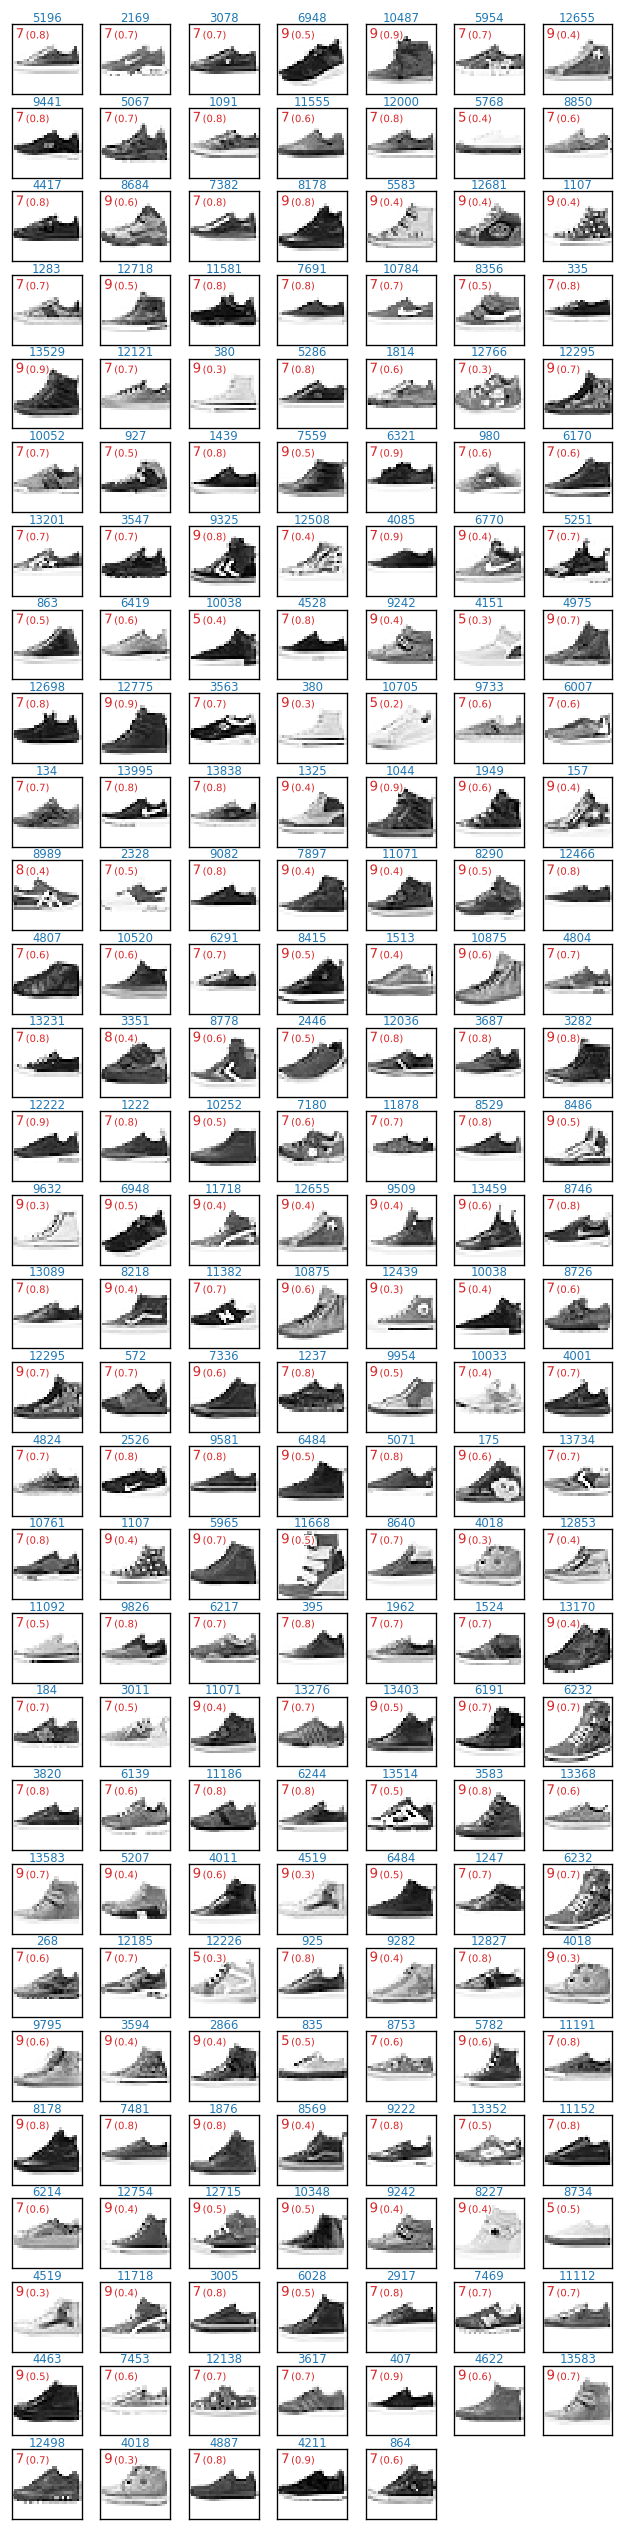

■ 正解値「8」に対して正しく予測（分類）できなかったケース


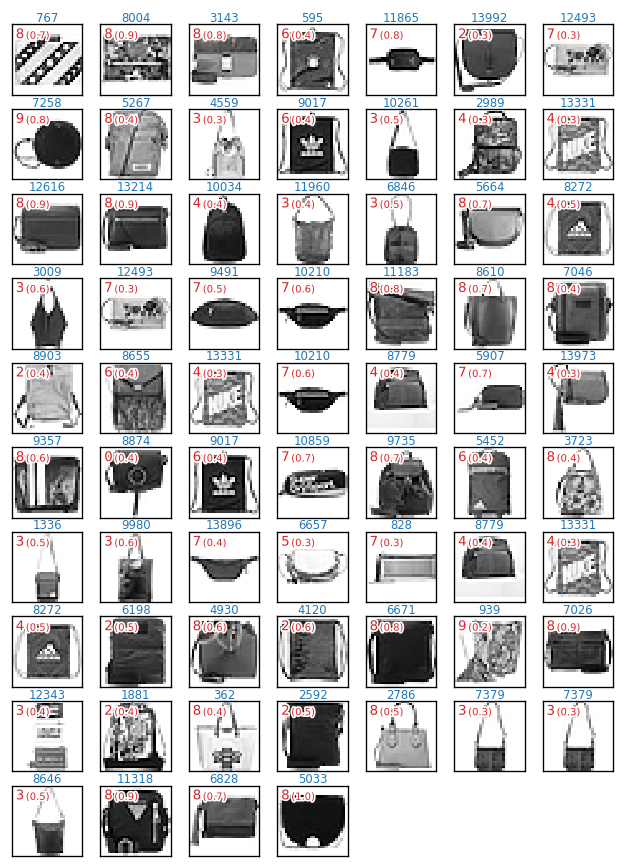

■ 正解値「9」に対して正しく予測（分類）できなかったケース


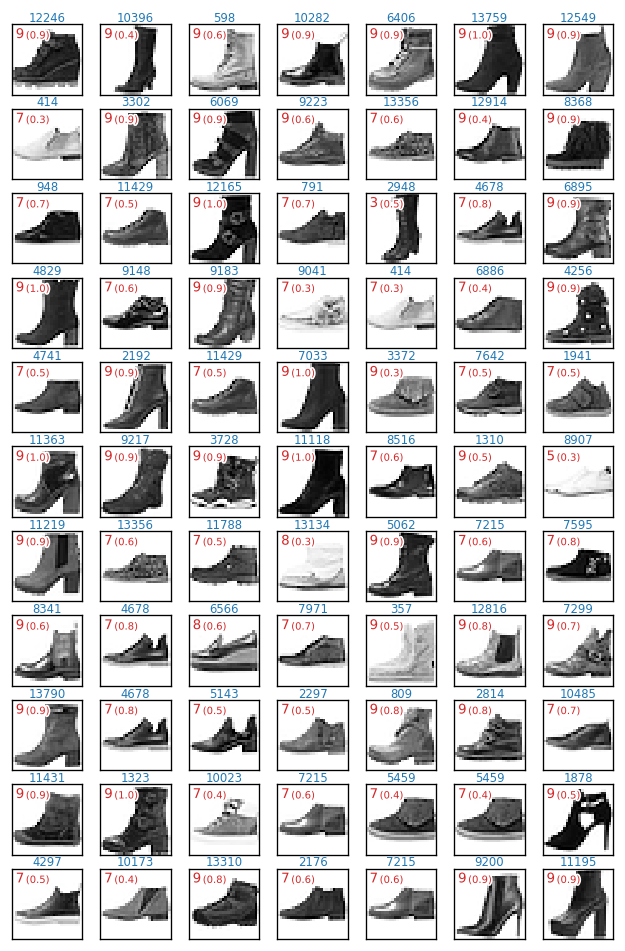

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

for t in range(0,10):

  print(f'■ 正解値「{t}」に対して正しく予測（分類）できなかったケース')

  # 正解値が t の行を抽出
  index_list = misclassified[t]

# 10%だけランダムにサンプリング（最低でも1つ表示するように）
  sample_size = max(1, len(index_list) // 10)  # 10分の1を選ぶ、最小でも1つは選ぶ
  sampled_indices = np.random.choice(index_list, size=sample_size, replace=False)


  # matplotlib 出力
  n_cols = 7
  n_rows = ((len(sampled_indices)-1)//n_cols)+1
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(6.5, 0.9*n_rows), dpi=120)
  for i, ax in enumerate(np.ravel(ax)):
        if i < len(sampled_indices):
            p = sampled_indices[i]
            image = X_test[p].reshape(28, 28)

            # 画像を表示
            ax.imshow(image, interpolation='nearest', vmin=0., vmax=1., cmap='Greys')

            # 予測（分類）を左上に表示
            t = ax.text(1, 1, f'{y_pred[p]}', verticalalignment='top', fontsize=8, color='tab:red')
            t.set_path_effects([pe.Stroke(linewidth=2, foreground='white'), pe.Normal()])

            # 予測（分離）に対応する出力層のニューロンの値を括弧で表示
            t = ax.text(5, 2, f'({model.predict_proba(X_test[p:p+1]).max():.1f})', verticalalignment='top', fontsize=6, color='tab:red')
            t.set_path_effects([pe.Stroke(linewidth=2, foreground='white'), pe.Normal()])

            # 目盛などを非表示に
            ax.tick_params(axis='both', which='both', left=False, labelleft=False,
                           bottom=False, labelbottom=False)

            # 青色でインデックスを表示
            ax.set_title(sampled_indices[i], fontsize=7, pad=1.5, color='tab:blue')
        else:
            ax.axis('off')  # 余白処理

  plt.show()